# ***Depression Dectection Using Text***


Step by step all steps to make model train everything given in assignment

## **1.Data Loading and simple Analysis**

### 1.1Load data 

In [2]:
import pandas as pd

df = pd.read_csv("dataset.csv")

df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


### 1.2 Basic Dataset Info

In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB


clean_text       0
is_depression    0
dtype: int64

In [3]:
df = df.dropna()
df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


### 1.3 Label Check

In [ ]:
df.columns
df['is_depression'].value_counts()

Index(['clean_text', 'is_depression'], dtype='object')

### 1.4 Text Length Feature and Statistical Analysis

In [4]:
df['length'] = df['clean_text'].apply(len)

df['length'].describe()

count     7731.000000
mean       361.383003
std        695.268030
min          3.000000
25%         58.000000
50%        110.000000
75%        362.500000
max      19822.000000
Name: length, dtype: float64

## **2 : Visualization(EDA)** 

### 2.1.Histogram

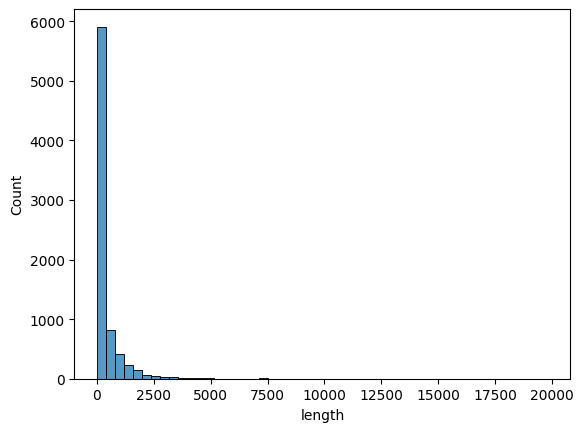

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['length'],bins=50)
plt.show()

### 2.2 Label Distribution(Countplot)

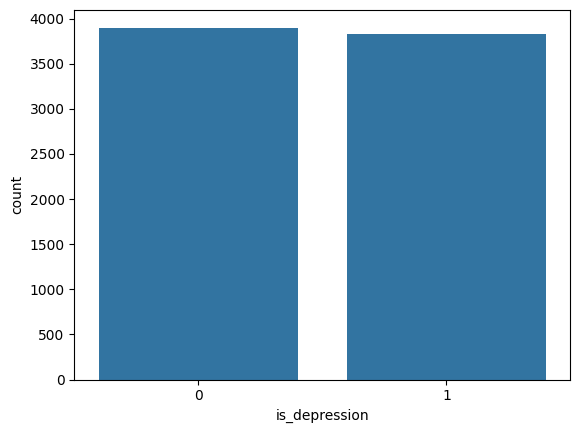

In [13]:
sns.countplot(x='is_depression', data=df)
plt.show()

### 2.3 Word Preprocessing (text cleaning)

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['clean_text'].apply(clean_text)

### 2.4 Outlier Detection

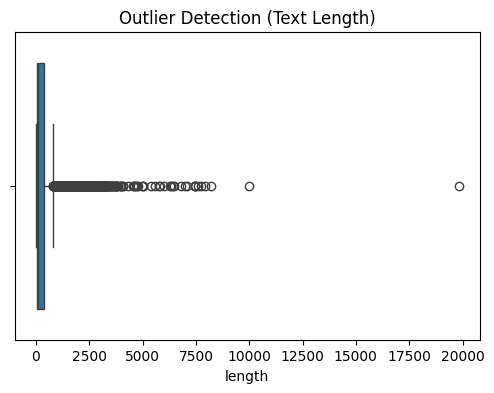

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['length'])
plt.title("Outlier Detection (Text Length)")
plt.show()

### 2.5 Corelation / Heatmap

In [6]:
corr = df[['length', 'is_depression']].corr()
print(corr)

                 length  is_depression
length         1.000000       0.423286
is_depression  0.423286       1.000000


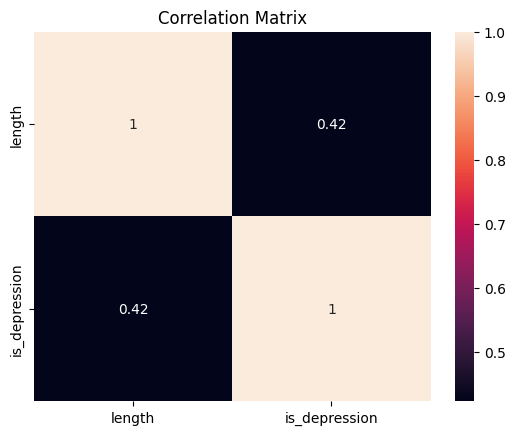

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['length', 'is_depression']].corr(),
            annot=True)

plt.title("Correlation Matrix")
plt.show()

##  **3.Model Training and Model Making** 

### 3.1 **Train-Test Split**

In [8]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['is_depression']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6184
Testing samples: 1547


### **3.2 Tokenization**

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

### **3.2 Padding**

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(6184, 100)
(1547, 100)


### **3.3 First Model (LSTM)**

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()

model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model.add(
    LSTM(64)
)

model.add(
    Dense(1, activation='sigmoid')
)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\GA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### **3.4 Train Lstm**

In [17]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.7307 - loss: 0.5737 - val_accuracy: 0.7551 - val_loss: 0.4924
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.8272 - loss: 0.3866 - val_accuracy: 0.8658 - val_loss: 0.3285
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.9012 - loss: 0.2687 - val_accuracy: 0.9192 - val_loss: 0.2356
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9535 - loss: 0.1368 - val_accuracy: 0.9588 - val_loss: 0.1283
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9830 - loss: 0.0659 - val_accuracy: 0.9434 - val_loss: 0.1797


### **3.5 Predictions**

In [18]:

y_pred_prob = model.predict(X_test_pad)

print(y_pred_prob[:5])

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
[[0.997468  ]
 [0.756535  ]
 [0.99758196]
 [0.9980929 ]
 [0.02967194]]


In [19]:
y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred[:10])

[[1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]]


## **4.MODEL EVALUATION**

### 4.1 Accuracy, Precision, Recall, F1

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9489334195216548
Precision: 0.9956584659913169
Recall   : 0.900523560209424
F1 Score : 0.9457044673539519


### 4.2.Confusion Matrix

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[780   3]
 [ 76 688]]


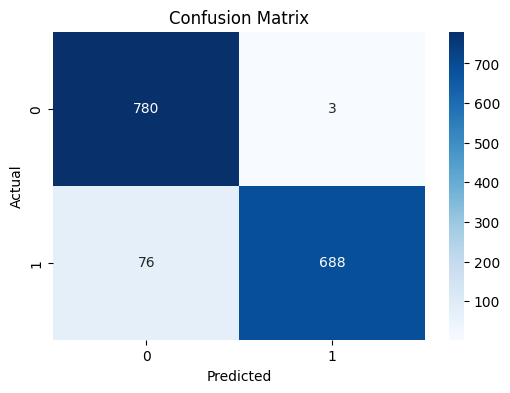

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### 4.3Classification Report

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       783
           1       1.00      0.90      0.95       764

    accuracy                           0.95      1547
   macro avg       0.95      0.95      0.95      1547
weighted avg       0.95      0.95      0.95      1547



### 3.4 ROC-AUC

In [26]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_prob)

print("ROC AUC Score:", auc)

ROC AUC Score: 0.9849108677191365


#### Now Lets Train one more model bcz sir say two 2 model train krny 

## **5.BiLSTM**

### **5.1 Training**

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

In [28]:
model_bilstm = Sequential()

model_bilstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_bilstm.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm.add(
    Dense(1, activation='sigmoid')
)

model_bilstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_bilstm.summary()

c:\Users\GA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_bilstm = model_bilstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - accuracy: 0.8991 - loss: 0.2598 - val_accuracy: 0.9628 - val_loss: 0.1268
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.9774 - loss: 0.0754 - val_accuracy: 0.9644 - val_loss: 0.1074
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.9891 - loss: 0.0327 - val_accuracy: 0.9612 - val_loss: 0.1140
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.9941 - loss: 0.0198 - val_accuracy: 0.9652 - val_loss: 0.1361
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.9956 - loss: 0.0142 - val_accuracy: 0.9580 - val_loss: 0.1448


### **5.2Predictions**

In [31]:
y_pred_prob_bilstm = model_bilstm.predict(X_test_pad)
y_pred_bilstm = (y_pred_prob_bilstm > 0.5).astype(int)
print(y_pred_bilstm)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [0]]


### **5.3 Evaluation**

#### **5.4 Accuracy, Precision, Recall, F1**

In [32]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred_bilstm)
precision = precision_score(y_test, y_pred_bilstm)
recall = recall_score(y_test, y_pred_bilstm)
f1 = f1_score(y_test, y_pred_bilstm)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9560439560439561
Precision: 0.9603174603174603
Recall   : 0.9502617801047121
F1 Score : 0.9552631578947368


#### **5.5 Confusion Matrix Graph**

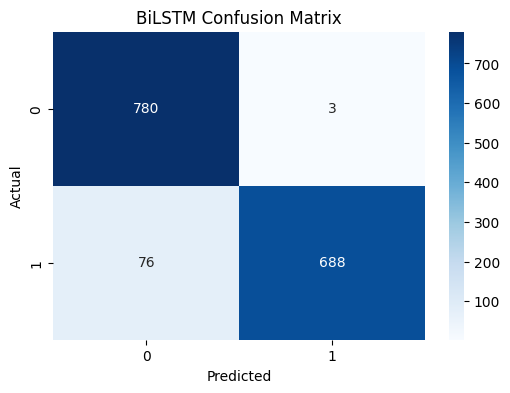

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")

plt.show()

#### **5.6 Confession Matrix Graph**

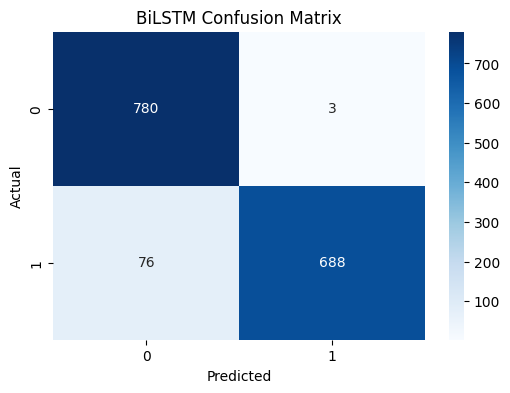

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")

plt.show()

#### **5.7 Classification Report**

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bilstm))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       783
           1       0.96      0.95      0.96       764

    accuracy                           0.96      1547
   macro avg       0.96      0.96      0.96      1547
weighted avg       0.96      0.96      0.96      1547



#### **5.8 ROC-AUC Score**

In [38]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_prob_bilstm)

print("ROC AUC Score:", auc)

ROC AUC Score: 0.9893465861600904


## **6.CNN-LSTM**

### 6.1 **CNN-LSTM Model**

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense

model_cnn_lstm = Sequential()

model_cnn_lstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_cnn_lstm.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    )
)

model_cnn_lstm.add(
    MaxPooling1D(pool_size=2)
)

model_cnn_lstm.add(
    LSTM(64)
)

model_cnn_lstm.add(
    Dense(1, activation='sigmoid')
)

model_cnn_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn_lstm.summary()

c:\Users\GA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### **6.2 Train**

In [40]:
history_cnn_lstm = model_cnn_lstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.8702 - loss: 0.3212 - val_accuracy: 0.9483 - val_loss: 0.1603
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9697 - loss: 0.1008 - val_accuracy: 0.9620 - val_loss: 0.1343
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9816 - loss: 0.0660 - val_accuracy: 0.9458 - val_loss: 0.1850
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9893 - loss: 0.0462 - val_accuracy: 0.9612 - val_loss: 0.1464
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.9937 - loss: 0.0301 - val_accuracy: 0.9499 - val_loss: 0.2112


### **6.3 Predicions**

In [42]:
y_pred_prob_cnn = model_cnn_lstm.predict(X_test_pad)

y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int)
print(y_pred_cnn)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [0]]


### **6.4 Evaluations**

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_cnn))
print("Precision:", precision_score(y_test, y_pred_cnn))
print("Recall   :", recall_score(y_test, y_pred_cnn))
print("F1 Score :", f1_score(y_test, y_pred_cnn))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_prob_cnn))

Accuracy : 0.9515190691661279
Precision: 0.9587217043941412
Recall   : 0.9424083769633508
F1 Score : 0.9504950495049505
ROC AUC  : 0.9854767206274698
